# Course assessment: project part "stock data" (M. Garcin)

## Numerical processing of financial data

#### Objective
The goal of this project is to assess the risk and the performance of a simple portfolio.

- Please write commented code. You can also use text cells for your comments and explanations.
- The code must follow the good coding principles (it must be clean, readable, etc.).
- Graphs must have a title, a legend and their axes must be labeled.
- At the end, submit your notebooks __and a pdf file of 5 to 8 pages__ into the Moodle Assignment you will find in the section "Assessment: projects".
This separate pdf file is intended to be a (very) short paper : a standalone document that summarizes the work you have carried out in the notebooks and the results you have obtained (being they positive or negative), with figures. It has to be self-contained in the sense that one has to be able to read your report and understand its content without having to look into your notebooks, which will be checked afterwards.


In [1]:
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

# Dataset

You will use the dataset (Excel files) of one-minute observations (OHLC prices) provided in Moodle for TP1 (Session 1). The dataset consists in the 40 constituents of the French stock index CAC 40 (as of 2022/2023). The biggest capitalizations are: LVMH (MC), L'Oréal (OR), TotalEnergies (TTE), Sanofi (SAN), Hermès (RMS), Airbus (AIR)...

You have first to restrict arbitrarily your investment universe to ten of these stocks and work with this universe for all the project.

The time range is September 2022-March 2023. Pay attention to the fact that some stocks don't have a price every minute (less liquid, like SW): avoid them.



In [2]:
# Dataset path
DATA_DIR = '/Users/anirudhsudhir/Ecole Python/dataset TP1'

# Selected investment universe
# 10 liquid CAC 40 stocks chosen to avoid missing minute-level data.
# Illiquid stocks (e.g., SW - Sodexo) are excluded.
TICKERS = ['AIR', 'BN', 'BNP', 'CA', 'DG', 'MC', 'OR', 'RMS', 'SAN', 'TTE']

# Creating a porfolio (Part 1)

* **1.a/** Split your dataset of prices in separate business days, from day 1 to day $n$. Calculate and put in a dataframe the price returns of the 10 stocks at a daily time scale.



(136, 10)
(135, 10)


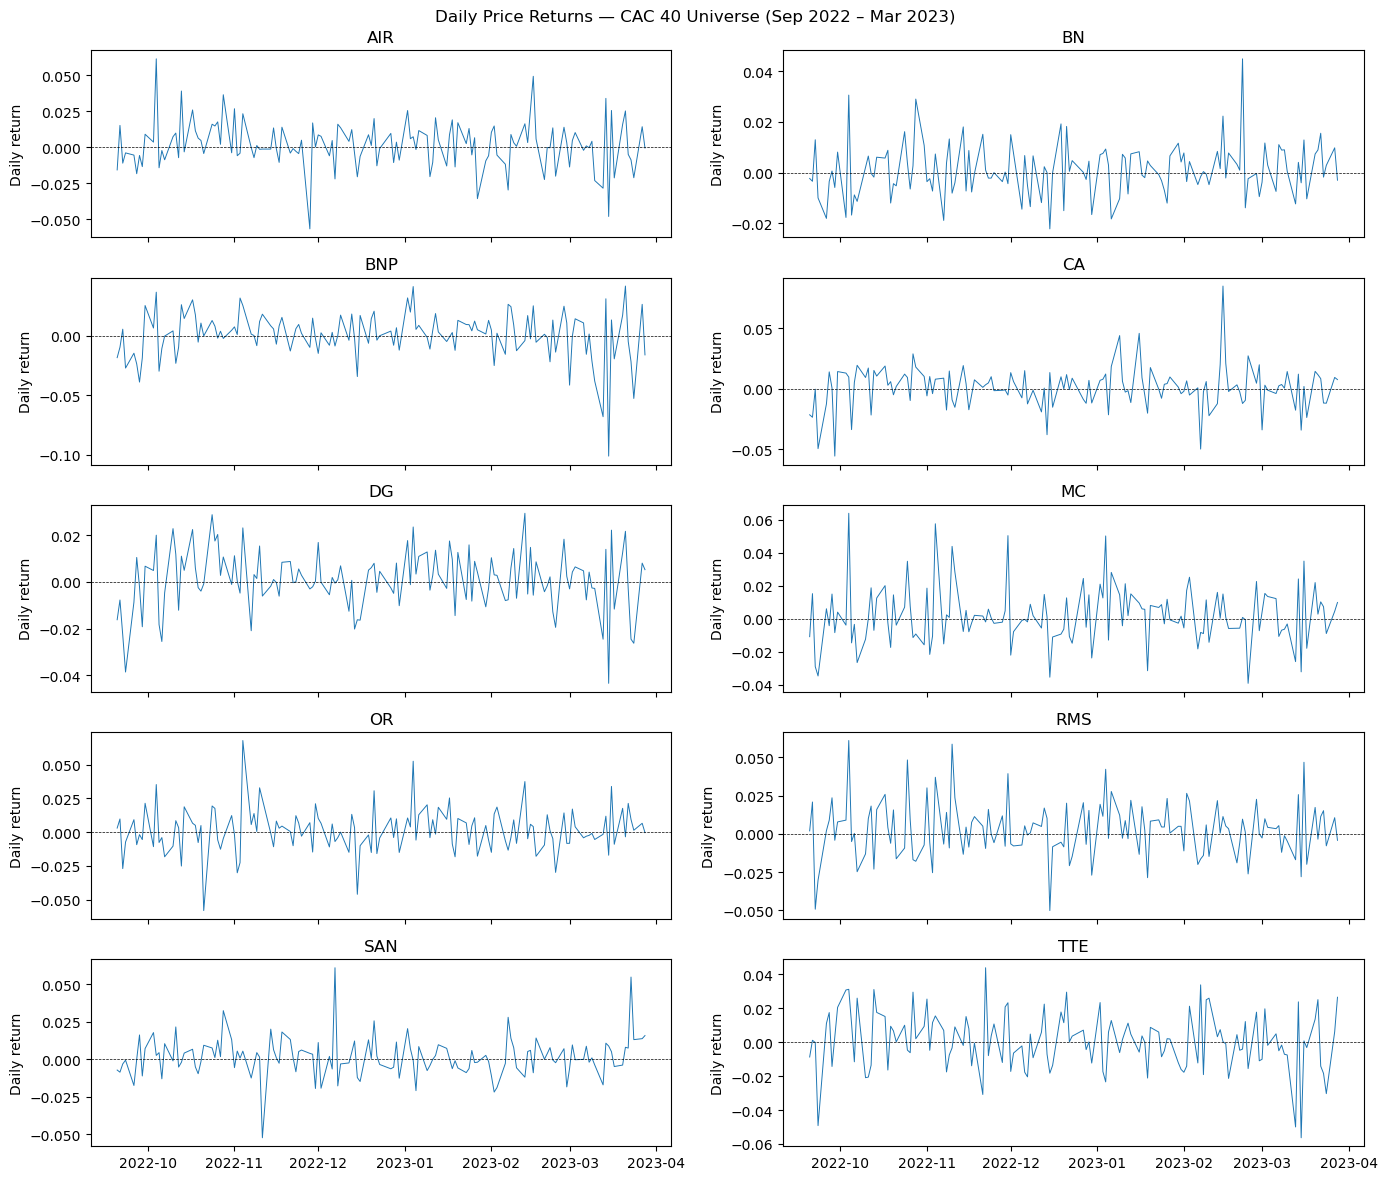

In [3]:
def load_daily_close(ticker, data_dir):
    """
    Load 1-minute OHLC data for a given ticker and extract the daily close price
    (last observation of each trading day).
    """
    path = os.path.join(data_dir, f'{ticker}_Prices.xlsx')
    df = pd.read_excel(path, header=1)  # second row (0-indexed) becomes the header

    df.columns = df.columns.str.strip().str.lower()

    time_col = df.columns[0]
    close_col = [c for c in df.columns if 'close' in c][0]

    df[time_col] = pd.to_datetime(df[time_col])
    df = df.set_index(time_col).sort_index()

    daily_close = df[close_col].groupby(df.index.date).last()
    daily_close.index = pd.to_datetime(daily_close.index)
    daily_close.name = ticker

    return daily_close


# Load all tickers
closes = {}

for ticker in TICKERS:
    closes[ticker] = load_daily_close(ticker, DATA_DIR)

prices_df = pd.DataFrame(closes).dropna()
print(prices_df.shape)
prices_df.head()


# Daily returns
returns_df = prices_df.pct_change().dropna()
print(returns_df.shape)
returns_df.head()


# Plot daily returns
fig, axes = plt.subplots(5, 2, figsize=(14, 12), sharex=True)
axes = axes.ravel()

for i, ticker in enumerate(TICKERS):
    axes[i].plot(returns_df.index, returns_df[ticker], linewidth=0.7)
    axes[i].set_title(ticker)
    axes[i].set_ylabel('Daily return')
    axes[i].axhline(0, color='black', linestyle='--', linewidth=0.5)

fig.suptitle('Daily Price Returns — CAC 40 Universe (Sep 2022 – Mar 2023)')
plt.tight_layout()
plt.show()

* **1.b/** Calculate both the correlation matrix and the covariance matrix $\Sigma$ of the daily price returns of the 10 stocks.

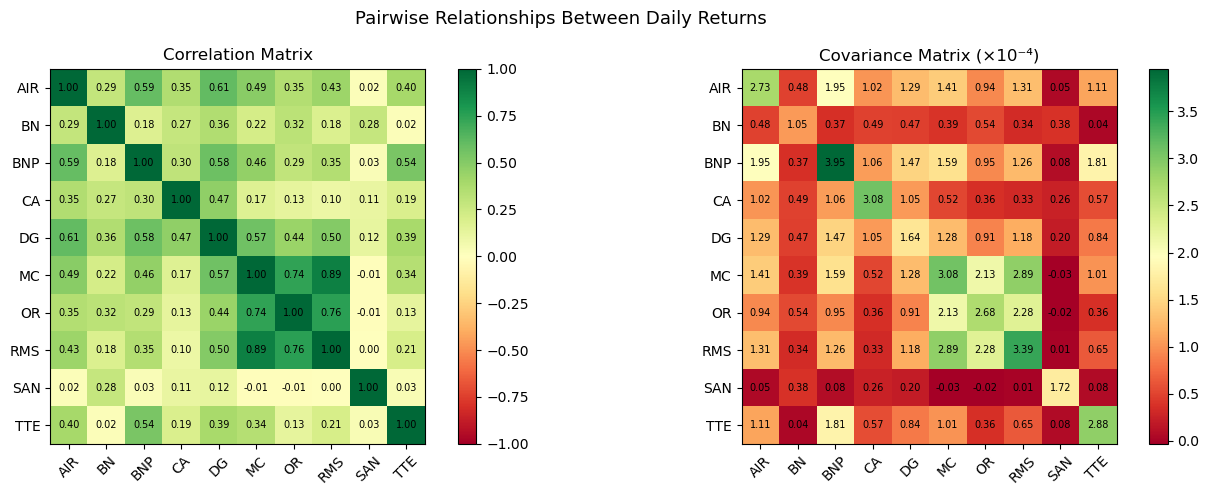

Correlation matrix (rounded):


,AIR,BN,BNP,CA,DG,MC,OR,RMS,SAN,TTE
AIR,1.000,0.285,0.594,0.352,0.607,0.487,0.349,0.429,0.022,0.397
BN,0.285,1.000,0.180,0.274,0.359,0.217,0.320,0.181,0.280,0.023
BNP,0.594,0.180,1.000,0.304,0.576,0.456,0.291,0.345,0.030,0.537
CA,0.352,0.274,0.304,1.000,0.468,0.167,0.126,0.101,0.111,0.193
DG,0.607,0.359,0.576,0.468,1.000,0.569,0.435,0.501,0.120,0.387
MC,0.487,0.217,0.456,0.167,0.569,1.000,0.741,0.893,-0.014,0.339
OR,0.349,0.320,0.291,0.126,0.435,0.741,1.000,0.757,-0.011,0.130
RMS,0.429,0.181,0.345,0.101,0.501,0.893,0.757,1.000,0.005,0.208
SAN,0.022,0.280,0.030,0.111,0.120,-0.014,-0.011,0.005,1.000,0.034
TTE,0.397,0.023,0.537,0.193,0.387,0.339,0.130,0.208,0.034,1.000



Covariance matrix (rounded):


,AIR,BN,BNP,CA,DG,MC,OR,RMS,SAN,TTE
AIR,0.000273,0.000048,0.000195,0.000102,0.000129,0.000141,0.000094,0.000131,0.000005,0.000111
BN,0.000048,0.000105,0.000037,0.000049,0.000047,0.000039,0.000054,0.000034,0.000038,0.000004
BNP,0.000195,0.000037,0.000395,0.000106,0.000147,0.000159,0.000095,0.000126,0.000008,0.000181
CA,0.000102,0.000049,0.000106,0.000308,0.000105,0.000052,0.000036,0.000033,0.000026,0.000057
DG,0.000129,0.000047,0.000147,0.000105,0.000164,0.000128,0.000091,0.000118,0.000020,0.000084
MC,0.000141,0.000039,0.000159,0.000052,0.000128,0.000308,0.000213,0.000289,-0.000003,0.000101
OR,0.000094,0.000054,0.000095,0.000036,0.000091,0.000213,0.000268,0.000228,-0.000002,0.000036
RMS,0.000131,0.000034,0.000126,0.000033,0.000118,0.000289,0.000228,0.000339,0.000001,0.000065
SAN,0.000005,0.000038,0.000008,0.000026,0.000020,-0.000003,-0.000002,0.000001,0.000172,0.000008
TTE,0.000111,0.000004,0.000181,0.000057,0.000084,0.000101,0.000036,0.000065,0.000008,0.000288


In [4]:
# Covariance and Correlation Matrices 
Sigma = returns_df.cov()        # Covariance matrix of daily returns
corr = returns_df.corr()        # Correlation matrix of daily returns

# Plot both matrices
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, matrix, title, fmt in zip(
    axes,
    [corr, Sigma * 1e4],  # scale covariance for better visualization
    ['Correlation Matrix', 'Covariance Matrix (×10⁻⁴)'],
    ['.2f', '.2f']):
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=-1 if 'Correlation' in title else None)
    
    # Ticker labels
    ax.set_xticks(range(len(TICKERS)))
    ax.set_xticklabels(TICKERS, rotation=45)
    ax.set_yticks(range(len(TICKERS)))
    ax.set_yticklabels(TICKERS)
    
    # Annotate values
    for i in range(len(TICKERS)):
        for j in range(len(TICKERS)):
            ax.text(j, i, f"{matrix.iloc[i,j]:{fmt}}", ha='center', va='center', fontsize=7)
    
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle('Pairwise Relationships Between Daily Returns', fontsize=13)
plt.tight_layout()
plt.show()

# Print matrices in notebook
print("Correlation matrix (rounded):")
display(corr.round(3))

print("\nCovariance matrix (rounded):")
display(Sigma.round(6))

* **1.c/** For each stock, calculate the autocorrelation of the daily time series of returns, for a lag of one day.

Lag-1 autocorrelation of daily returns:


AIR   -0.1770
BN    -0.1927
BNP   -0.0128
CA     0.0066
DG    -0.0243
MC    -0.1936
OR    -0.1689
RMS   -0.1747
SAN   -0.0353
TTE   -0.0828
dtype: float64

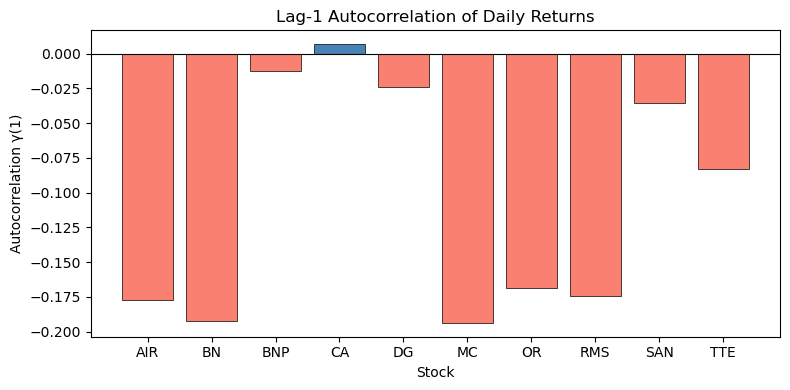

In [5]:
# Lag-1 Autocorrelation of Daily Returns
# γ(1) = Corr(r_t, r_{t-1}) for each stock
autocorr = returns_df.apply(lambda col: col.autocorr(lag=1))

print("Lag-1 autocorrelation of daily returns:")
display(autocorr.round(4))

# Plot autocorrelation
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['steelblue' if v >= 0 else 'salmon' for v in autocorr.values]  # positive - blue, negative - red

ax.bar(autocorr.index, autocorr.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)

ax.set_title('Lag-1 Autocorrelation of Daily Returns')
ax.set_ylabel('Autocorrelation γ(1)')
ax.set_xlabel('Stock')

plt.tight_layout()
plt.show()

* **1.d/** Using only the autocorrelations calculated above and the observation of the price returns at day $i$ (for $1\leq i\leq n-1$), propose a projection $R_{i+1,j}$ of the future price return at day $i+1$ for each stock $j$ ($1\leq j\leq 10$). Justify briefly the relevance of the method.



In [6]:
# Project future returns using lag-1 autocorrelation
# Formula: R_{i+1,j} = γ_j(1) * r_{i,j}
# Assumes a simple AR(1) model for returns: r_{t,j} = γ_j * r_{t-1,j} + ε_t

# Use returns from day 1 to n-1 to project returns for day 2 to n
R_projected = returns_df.iloc[:-1].multiply(autocorr, axis=1)
R_projected.index = returns_df.index[1:]  # align with day i+1

print("Projected returns (first 5 rows):")
display(R_projected.head().round(5))

Projected returns (first 5 rows):


,AIR,BN,BNP,CA,DG,MC,OR,RMS,SAN,TTE
2022-09-21,0.00279,0.00045,0.00024,-0.00014,0.00039,0.00211,-0.00051,-0.00035,0.00025,0.00072
2022-09-22,-0.00269,0.00066,0.00013,-0.00016,0.00019,-0.00293,-0.00164,-0.00365,0.00030,-0.00009
2022-09-23,0.00195,-0.00250,-0.00007,-0.00000,0.00055,0.00563,0.00456,0.00859,0.00011,0.00002
2022-09-26,0.00069,0.00193,0.00035,-0.00033,0.00094,0.00672,0.00124,0.00528,0.00002,0.00407
2022-09-27,0.00096,0.00348,0.00019,-0.00008,0.00021,-0.00116,-0.00156,-0.00037,0.00061,-0.00092


**Justification**

Lag-1 autocorrelation measures the linear predictability of tomorrow’s return from today’s return. Under a stationary AR(1) model, the best linear predictor of $r_{i+1,j}$ is $\gamma_j(1)\, r_{i,j}$.

If $\gamma_j(1) \approx 0$ (as implied by the weak-form Efficient Market Hypothesis), the projected returns will be close to zero.

* **1.e/** Using the above projection as a proxy for the expected return, calculate the Markowitz portfolio such that the sum of weights is equal to 1, that is the optimal vector of weights for day $i+1$ is
$$\Omega_{i+1}=\frac{1}{\mathbf{1}'_{10}\Sigma^{-1}R_{i+1}}\Sigma^{-1}R_{i+1},$$
where $R_{i+1}=(R_{i+1,1},...,R_{i+1,10})'$ and $\mathbf{1}_{10}$ is a vector of ones of size 10.



Portfolio weights (first 5 rows):


,AIR,BN,BNP,CA,DG,MC,OR,RMS,SAN,TTE
2022-09-21,7.532,0.637,-3.693,-1.746,-2.590,19.884,-4.127,-14.795,1.474,-1.576
2022-09-22,-43.461,24.756,16.020,-8.356,46.436,-13.221,11.383,-32.081,-4.721,4.246
2022-09-23,-4.209,19.382,2.982,-3.659,6.961,9.123,-1.154,-24.614,-4.599,0.788
2022-09-26,-0.356,1.269,-0.459,-0.057,-0.570,1.960,-1.295,0.083,-0.178,0.603
2022-09-27,0.115,2.241,0.118,-0.222,-0.194,-0.660,-1.021,0.983,-0.303,-0.056



Row sums (should all be 1): [1.]


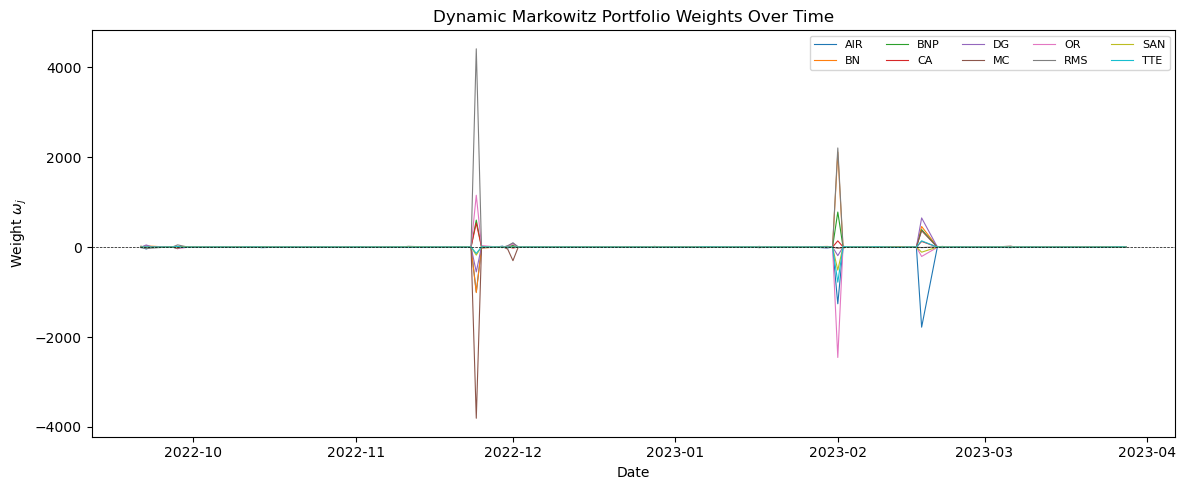

In [7]:
# Markowitz Portfolio Weights with Unit-Sum Constraint
# Ω_{i+1} = Σ⁻¹ R_{i+1} / (1' Σ⁻¹ R_{i+1})
# Σ is fixed (full-sample covariance), R_{i+1} = projected return for day i+1

Sigma_inv = np.linalg.inv(Sigma.values)  # inverse covariance matrix
ones = np.ones(len(TICKERS))             # vector of ones

weights_list = []

for date, R_row in R_projected.iterrows():
    R = R_row.values                     # projected returns vector
    raw = Sigma_inv @ R
    denom = ones @ raw

    # Avoid division by zero
    if abs(denom) < 1e-12:
        w = np.ones(len(TICKERS)) / len(TICKERS)
    else:
        w = raw / denom

    weights_list.append(w)

# Convert to DataFrame
weights_df = pd.DataFrame(weights_list, index=R_projected.index, columns=TICKERS)

print("Portfolio weights (first 5 rows):")
display(weights_df.head().round(3))

# Verify row sums = 1
print(f"\nRow sums (should all be 1): {weights_df.sum(axis=1).round(6).unique()}")

# Plot dynamic portfolio weights
fig, ax = plt.subplots(figsize=(12, 5))
for ticker in TICKERS:
    ax.plot(weights_df.index, weights_df[ticker], label=ticker, linewidth=0.8)

ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Dynamic Markowitz Portfolio Weights Over Time')
ax.set_ylabel('Weight $\\omega_j$')
ax.set_xlabel('Date')
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

* **1.f/** Add in your dataframe the time series of realized price returns for your portfolio, between day 2 and day $n$, using the dynamic weights calculated above.



Full returns DataFrame (last 5 rows):


,AIR,BN,BNP,CA,DG,MC,OR,RMS,SAN,TTE,Portfolio
2023-03-22,-0.0049,0.0155,-0.0049,0.0084,-0.0030,0.0102,0.0213,0.0114,0.0075,-0.0141,-0.0061
2023-03-23,-0.0088,-0.0018,-0.0218,-0.0117,-0.0246,0.0072,0.0094,0.0152,0.0548,-0.0184,0.0092
2023-03-24,-0.0212,0.0029,-0.0527,-0.0119,-0.0263,-0.0090,0.0014,-0.0078,0.0131,-0.0303,0.0749
2023-03-27,0.0143,0.0098,0.0262,0.0094,0.0081,0.0044,0.0065,0.0106,0.0138,0.0062,-0.0314
2023-03-28,-0.0005,-0.0030,-0.0162,0.0076,0.0053,0.0098,-0.0004,-0.0042,0.0158,0.0265,-0.0112


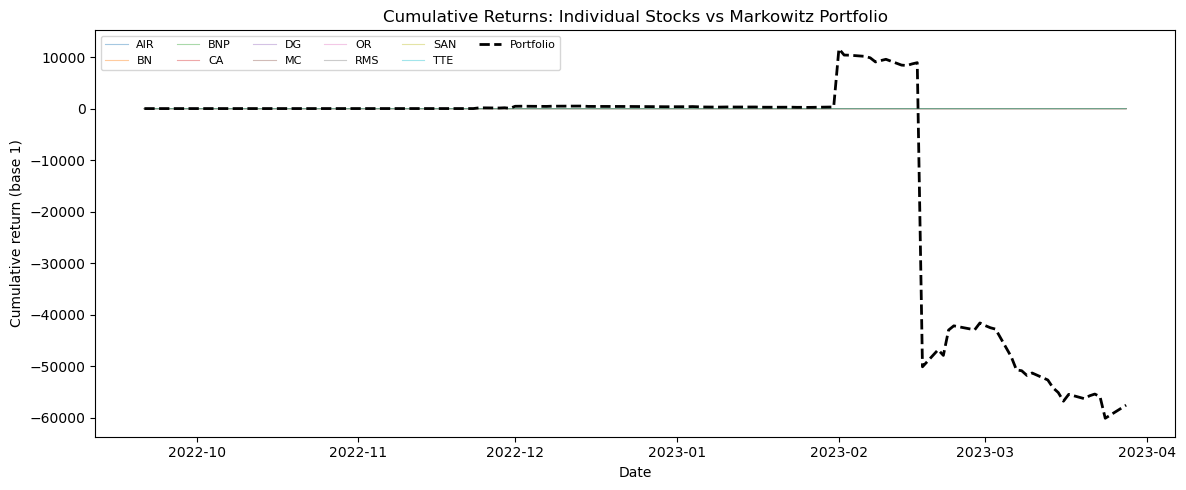

In [8]:
# Realized portfolio returns
# Ω_{i+1}' · r_{i+1} = weighted sum of actual returns using dynamic weights

# Actual returns from day 2 to n
actual_returns = returns_df.iloc[1:]  

# Portfolio return = row-wise dot product of weights and actual returns
portfolio_returns = (weights_df * actual_returns).sum(axis=1)
portfolio_returns.name = 'Portfolio'

# Add portfolio returns to a single DataFrame
full_df = actual_returns.copy()
full_df['Portfolio'] = portfolio_returns

print("Full returns DataFrame (last 5 rows):")
display(full_df.tail().round(4))

# Plot cumulative returns 
fig, ax = plt.subplots(figsize=(12, 5))

cumulative = (1 + full_df).cumprod()  

# Individual stock returns 
for ticker in TICKERS:
    ax.plot(cumulative.index, cumulative[ticker], alpha=0.4, linewidth=0.8, label=ticker)

# Portfolio cumulative return 
ax.plot(cumulative.index, cumulative['Portfolio'], color='black',
        linewidth=2, linestyle='--', label='Portfolio')

ax.set_title('Cumulative Returns: Individual Stocks vs Markowitz Portfolio')
ax.set_ylabel('Cumulative return (base 1)')
ax.set_xlabel('Date')
ax.legend(ncol=6, fontsize=8)

plt.tight_layout()
plt.show()

* **1.g/** What is the main methodological bias we had in the construction of this portfolio that would affect the quality of a backtest?

The main bias in this portfolio construction is look-ahead bias. We estimate the covariance matrix $\Sigma$ on the full sample and use it to compute daily weights, including for early days. In reality, $\Sigma$ should only use data available up to day $i$. Using future information inflates the apparent backtest performance. A proper backtest would rely on a rolling or expanding window for $\Sigma$ estimation.

# Risk and performance evaluation (Part 2)

* **2.a/** Determine the ex-ante (that is using $R_{i+1,j}$ as the return) and ex-post (that is the real return observed after each trading day) Sharpe ratio of your portfolio (consider 0 as the risk-free rate).

In [9]:
# Risk-free rate
rf = 0  # as specified

# Ex-ante Sharpe ratio: using projected returns R_{i+1}
# Portfolio projected return at day i+1 = Ω_{i+1}' · R_{i+1}
portfolio_projected = (weights_df * R_projected).sum(axis=1)

sharpe_exante = (portfolio_projected.mean() - rf) / portfolio_projected.std()
sharpe_exante_annualised = sharpe_exante * np.sqrt(252)  

# Ex-post Sharpe ratio: using realized returns
sharpe_expost = (portfolio_returns.mean() - rf) / portfolio_returns.std()
sharpe_expost_annualised = sharpe_expost * np.sqrt(252)

# Display results
print("=== Sharpe Ratio (risk-free rate = 0) ===")
print(f"  Ex-ante  (daily): {sharpe_exante:.4f}   Annualised: {sharpe_exante_annualised:.4f}")
print(f"  Ex-post  (daily): {sharpe_expost:.4f}   Annualised: {sharpe_expost_annualised:.4f}")
print("Note: the gap between ex-ante and ex-post Sharpe reflects the quality of the autocorrelation-based return projections.")

=== Sharpe Ratio (risk-free rate = 0) ===
  Ex-ante  (daily): -0.0096   Annualised: -0.1522
  Ex-post  (daily): 0.1200   Annualised: 1.9054
Note: the gap between ex-ante and ex-post Sharpe reflects the quality of the autocorrelation-based return projections.


* **2.b/** Calculate the ex-post upside potential ratio of your portfolio.

In [10]:
# Ex-post Upside Potential Ratio
# U(r*) = E[max(r - r*, 0)] / sqrt(E[min(r - r*, 0)^2])
# Using r* = 0 as the risk-free rate

r_star = 0.0
excess = portfolio_returns - r_star

# Numerator: average of positive deviations
upside = np.maximum(excess, 0).mean()

# Denominator: square root of average squared negative deviations
downside = np.sqrt((np.minimum(excess, 0) ** 2).mean())

# Upside Potential Ratio
upside_potential_ratio = upside / downside if downside > 0 else np.inf

# Display results
print("=== Ex-post Upside Potential Ratio (r* = 0) ===")
print(f"  Upside numerator   E[max(r,0)]:          {upside:.6f}")
print(f"  Downside denom  sqrt(E[min(r,0)^2]):      {downside:.6f}")
print(f"  Upside Potential Ratio:                   {upside_potential_ratio:.4f}")
print("Interpretation: a ratio > 1 means the average gain exceeds the average loss.")

=== Ex-post Upside Potential Ratio (r* = 0) ===
  Upside numerator   E[max(r,0)]:          0.512159
  Downside denom  sqrt(E[min(r,0)^2]):      0.577041
  Upside Potential Ratio:                   0.8876
Interpretation: a ratio > 1 means the average gain exceeds the average loss.


* **2.c/** Calculate the maximum drawdown of your portfolio.

=== Maximum Drawdown ===
  MDD:        6.1805 (618.05%)
  Reached on: 2023-03-24


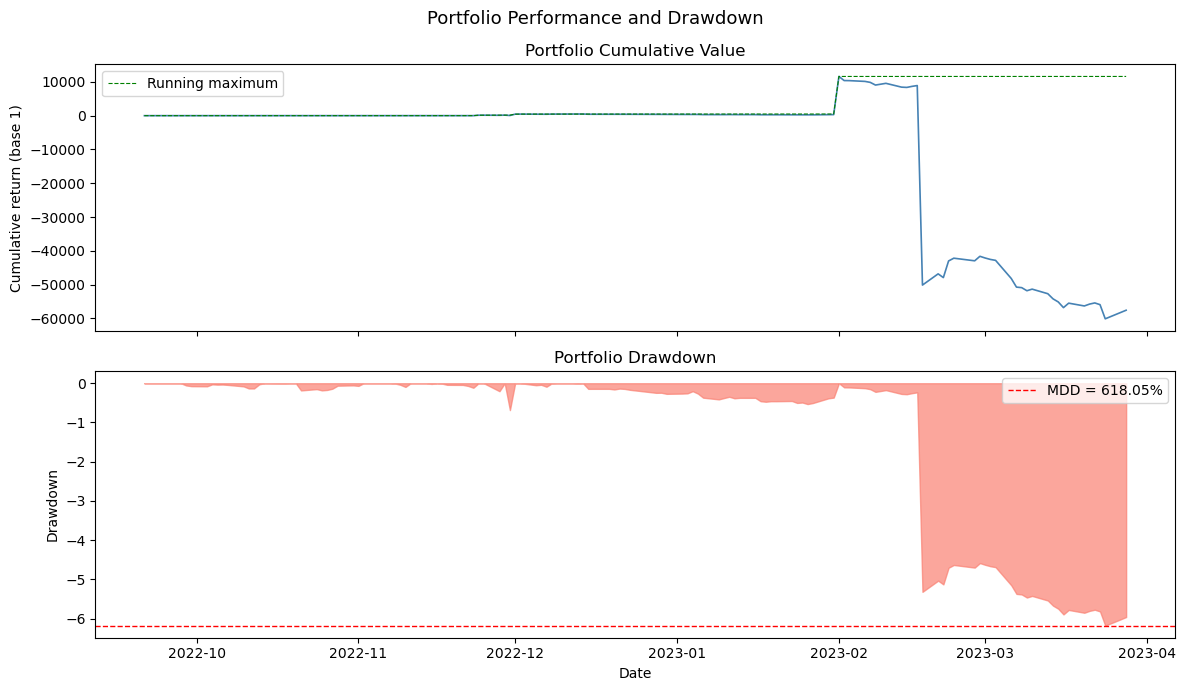

In [11]:
# Maximum Drawdown (MDD) 
# MDD = max_{1 ≤ i < j ≤ n} [ -(P_j - P_i) / P_i ]
# Computed via: drawdown at each point = -(P_t / running_max_t - 1)

# Reconstruct cumulative portfolio value (base 1)
cum_portfolio = (1 + portfolio_returns).cumprod()

# Running maximum up to each date
running_max = cum_portfolio.cummax()

# Drawdown at each date
drawdown = -(cum_portfolio / running_max - 1)

# Maximum drawdown and the date it occurred
MDD = drawdown.max()
MDD_date = drawdown.idxmax()

# Display results
print("=== Maximum Drawdown ===")
print(f"  MDD:        {MDD:.4f} ({MDD*100:.2f}%)")
print(f"  Reached on: {MDD_date.date()}")

# Plot cumulative value and drawdown
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Cumulative portfolio value
axes[0].plot(cum_portfolio.index, cum_portfolio.values, color='steelblue', linewidth=1.2)
axes[0].plot(running_max.index, running_max.values, color='green', linestyle='--', 
             linewidth=0.8, label='Running maximum')
axes[0].set_title('Portfolio Cumulative Value')
axes[0].set_ylabel('Cumulative return (base 1)')
axes[0].legend()

# Drawdown plot
axes[1].fill_between(drawdown.index, -drawdown.values, 0, color='salmon', alpha=0.7)
axes[1].axhline(-MDD, color='red', linestyle='--', linewidth=1, 
                label=f'MDD = {MDD*100:.2f}%')
axes[1].set_title('Portfolio Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.suptitle('Portfolio Performance and Drawdown', fontsize=13)
plt.tight_layout()
plt.show()

* **2.d/** Using the formula presented in the course, calculate the additive contribution of each of the 10 stocks to the volatility of the portfolio.

=== Additive Volatility Contribution ===
       Avg Weight  Individual Vol  Vol Contribution  Contribution (%)
Stock                                                                
AIR      -30.7109          0.0165            0.2037           37.6363
BN        12.8811          0.0103            0.0106            1.9591
BNP       13.5197          0.0199            0.0070            1.2950
CA         5.7358          0.0175            0.0010            0.1813
DG        -0.1318          0.0128           -0.0000           -0.0023
MC       -28.4008          0.0176           -0.0869          -16.0522
OR       -10.5444          0.0164           -0.0331           -6.1167
RMS       50.3167          0.0185            0.4133           76.3739
SAN       -6.1586          0.0132            0.0035            0.6403
TTE       -5.5068          0.0170            0.0222            4.1103

Sum of contributions: 0.541284
Portfolio volatility:  0.541149
(These should match — confirming the decomposition)


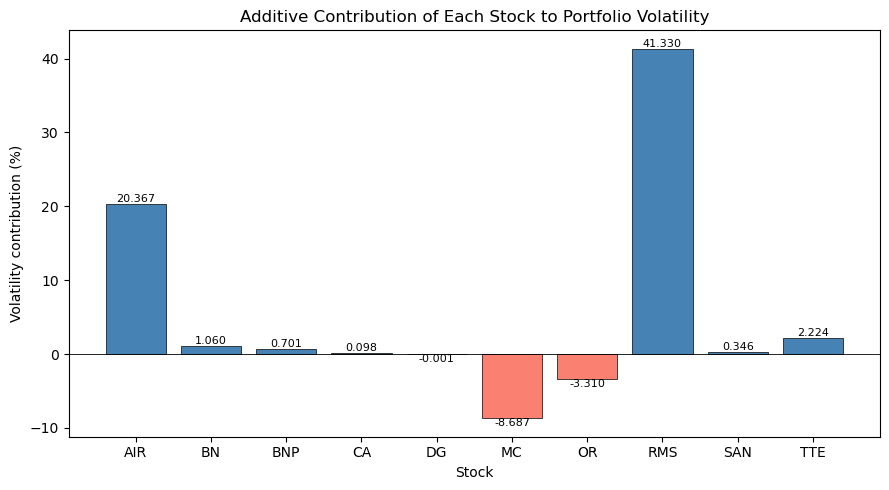


Note: negative contributions arise from short positions reducing overall volatility.


In [12]:
# Additive Contribution of Each Stock to Portfolio Volatility
# Formula:
# Contrib_i = w_i * σ_i * Σ_j (w_j * ρ_{ij} * σ_j) / σ(R)
# Where:
#   w_i      = portfolio weight of asset i
#   σ_i      = volatility of asset i
#   ρ_{ij}   = correlation between asset i and j
#   σ(R)     = portfolio volatility

# Use average weights over the period for a single, interpretable decomposition
w_avg = weights_df.mean().values
sigma_i = actual_returns.std().values
corr_matrix = actual_returns.corr().values

# Portfolio volatility
sigma_portfolio = np.sqrt(w_avg @ Sigma.values @ w_avg)

# Compute contribution of each asset
contributions = np.zeros(len(TICKERS))
for i in range(len(TICKERS)):
    inner_sum = sum(w_avg[j] * corr_matrix[i, j] * sigma_i[j] for j in range(len(TICKERS)))
    contributions[i] = (w_avg[i] * sigma_i[i] * inner_sum) / sigma_portfolio

# Combine into a DataFrame
contrib_df = pd.DataFrame({'Stock': TICKERS,
                           'Avg Weight': w_avg,
                           'Individual Vol': sigma_i,
                           'Vol Contribution': contributions,
                           'Contribution (%)': contributions / sigma_portfolio * 100
                          }).set_index('Stock')

# Display results
print("=== Additive Volatility Contribution ===")
print(contrib_df.round(4).to_string())
print(f"\nSum of contributions: {contributions.sum():.6f}")
print(f"Portfolio volatility:  {sigma_portfolio:.6f}")
print("(These should match — confirming the decomposition)")

# Plot contributions
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue' if v >= 0 else 'salmon' for v in contributions]
bars = ax.bar(TICKERS, contributions * 100, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('Additive Contribution of Each Stock to Portfolio Volatility')
ax.set_ylabel('Volatility contribution (%)')
ax.set_xlabel('Stock')

# Annotate bars
for bar, val in zip(bars, contributions * 100):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0002 * (1 if val >= 0 else -1),
            f'{val:.3f}', ha='center',
            va='bottom' if val >= 0 else 'top',
            fontsize=8)

plt.tight_layout()
plt.show()

print("\nNote: negative contributions arise from short positions reducing overall volatility.")